In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
df  = pd.read_excel('plan_coculture.xlsx', sheet_name='CFUs', skiprows=1)

In [25]:
# Calculate CFUs/mL

In [26]:
np.power(10, 0)

np.int64(1)

In [27]:
def calc_cfu(dilution, count, drop_volume = 5):
    """
    Drop volume in uL
    """
    drop_volume_mL = drop_volume/1000
    CFU_per_mL = (count/drop_volume_mL)*np.power(10, -dilution) 
    return CFU_per_mL

In [34]:
data = []
for _, row in df.iterrows():
    auxotroph_cfu = calc_cfu(row['Dilution.1'], row['Count.1'])
    if not pd.isna(row['Strain 1']):
        partner_cfu = calc_cfu(row['Dilution'], row['Count'])
        partner = row['Strain 1']
    else:
        partner = 'Monoculture'
        partner_cfu = np.nan
    data.append([partner, row['Strain 2'], row['Well'], auxotroph_cfu, partner_cfu, row['Unnamed: 7']])
    

In [35]:
cfu_df = pd.DataFrame(data, columns=['Partner', 'Auxotroph', 'Well', 
                                     'Auxotroph abundance [CFU/mL]', 'Partner abundance [CFUs/mL]', 'Plate'])


In [36]:
cfu_df

,Partner,Auxotroph,Well,Auxotroph abundance [CFU/mL],Partner abundance [CFUs/mL],Plate
0,brnQ,metB,A1,12000000.0,1.000000e+09,1
1,brnQ,metB,A2,10000000.0,7.000000e+08,1
2,brnQ,metB,A3,10000000.0,7.200000e+08,1
3,brnQ,metB,A4,6000000.0,7.400000e+08,1
4,cstA,metB,A5,6200000.0,8.000000e+08,1
...,...,...,...,...,...,...
71,proP,proC,A8,3200000.0,7.400000e+08,2
72,Monoculture,proC,A9,300000.0,NaN,2
73,Monoculture,proC,A10,320000.0,NaN,2
74,Monoculture,proC,A11,300000.0,NaN,2


In [31]:
cfu_df.to_csv('CFUs.csv')

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_40720/3344527010.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_40720/3344527010.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_40720/3344527010.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


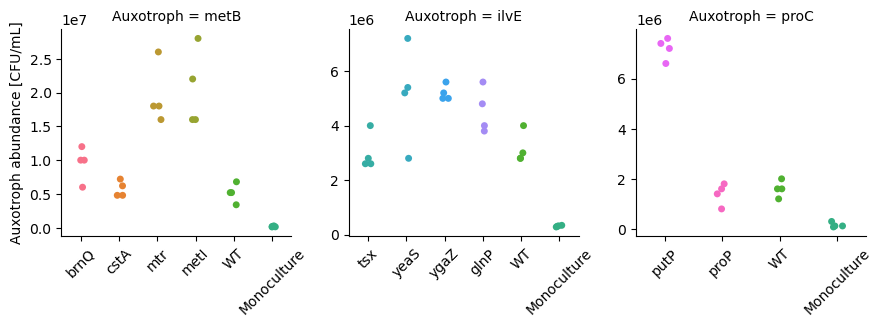

In [48]:
g = sns.catplot(data = cfu_df.loc[cfu_df.Plate==1], x = 'Partner', kind = 'strip', col = 'Auxotroph', y = 'Auxotroph abundance [CFU/mL]',
            hue = 'Partner', col_wrap=3, sharex=False, sharey=False, height = 3)
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.set_xlabel('')
# ax.set_ylabel('Auxotroph abundance [CFU/mL]', fontsize = 7)
# plt.tight_layout()

In [59]:
# Filter for Plate 1 (or your plate of interest)
df_plot = cfu_df.loc[cfu_df.Plate == 1]

# Pivot so each partner is a column, indexed by Auxotroph and Well
pivot = df_plot.pivot_table(index=['Partner', 'Well'], columns='Auxotroph', values='Auxotroph abundance [CFU/mL]').reset_index()

# # Compute difference to WT for each partner (excluding WT itself)
# for partner in pivot.columns:
#     if partner != 'WT':
#         pivot[f'diff_{partner}_vs_WT'] = pivot[partner] - pivot['WT']

# # Example: show the differences
# diff_cols = [col for col in pivot.columns if col.startswith('diff_')]
# print(pivot[diff_cols].head())

In [61]:
pivot = pivot.loc[pivot.Partner != 'Monoculture']

In [68]:
diff_data = []
for auxotroph in df_plot['Auxotroph'].unique():
    wt_mean = df_plot.loc[(df_plot.Partner == 'WT')&(df_plot.Auxotroph == auxotroph), 'Auxotroph abundance [CFU/mL]'].mean()
    aux_data = df_plot.loc[df_plot.Auxotroph == auxotroph].copy()
    for i, row in aux_data.iterrows():
        if row['Partner'] in ['WT', 'Monoculture']:
            continue
        diff = row['Auxotroph abundance [CFU/mL]'] - wt_mean
        diff_data.append([row['Partner'], auxotroph, row['Well'], diff])
diff_df = pd.DataFrame(diff_data, columns=['Partner', 'Auxotroph', 'Well', 'Difference_vs_WT'])

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_40720/1010816180.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_40720/1010816180.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_40720/1010816180.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


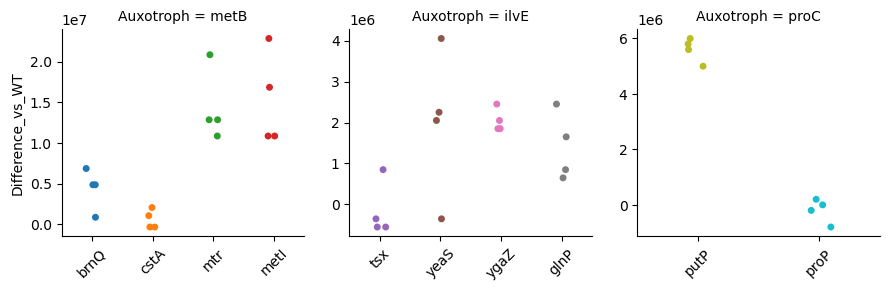

In [70]:
g = sns.catplot(data = diff_df, x = 'Partner', kind = 'strip', col = 'Auxotroph', y = 'Difference_vs_WT',
            hue = 'Partner', col_wrap=3, sharex=False, sharey=False, height = 3)
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.set_xlabel('')
# ax.set_ylabel('Auxotroph abundance [CFU/mL]', fontsize = 7)
# plt.tight_layout()